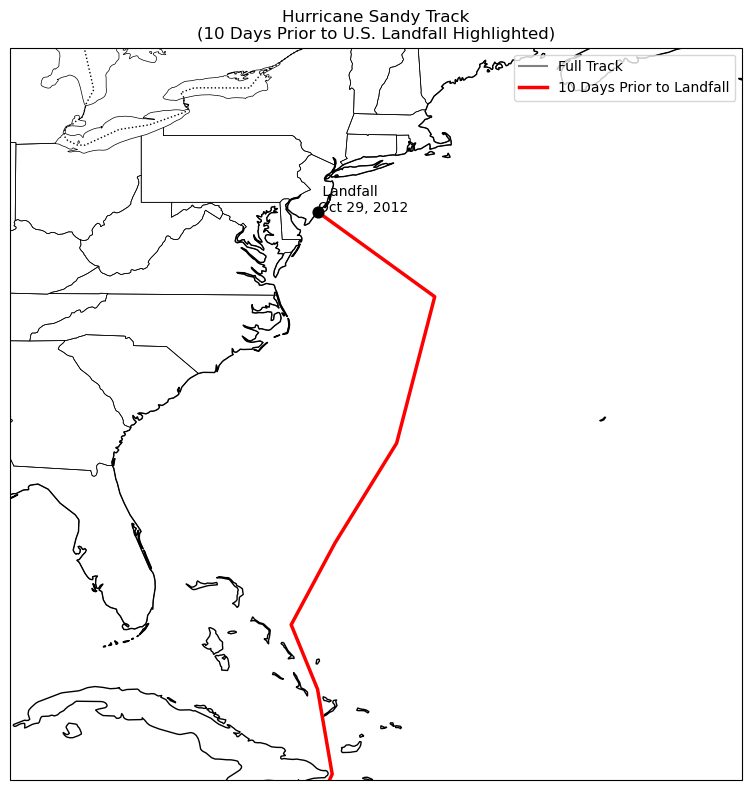

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime

# --- Sandy best track (subset from HURDAT2, 6-hourly) ---
data = [
    # Date (UTC), Lat, Lon
    ("2012-10-19 18:00", 13.5, -78.0),
    ("2012-10-20 00:00", 13.6, -78.5),
    ("2012-10-20 06:00", 13.8, -79.0),
    ("2012-10-20 12:00", 14.0, -79.4),
    ("2012-10-21 00:00", 14.6, -80.0),
    ("2012-10-22 00:00", 15.8, -76.9),
    ("2012-10-23 00:00", 18.0, -75.0),
    ("2012-10-24 00:00", 20.2, -74.0),
    ("2012-10-25 00:00", 23.1, -74.5),
    ("2012-10-26 00:00", 25.3, -75.4),
    ("2012-10-27 00:00", 28.1, -73.9),
    ("2012-10-28 00:00", 31.5, -71.8),
    ("2012-10-29 00:00", 36.5, -70.5),
    ("2012-10-29 18:00", 39.4, -74.5),  # Landfall NJ
]

df = pd.DataFrame(data, columns=["time", "lat", "lon"])
df["time"] = pd.to_datetime(df["time"])

# --- Define landfall time ---
landfall_time = datetime(2012, 10, 29, 18)

# --- Select 10 days prior ---
ten_days_prior = landfall_time - pd.Timedelta(days=10)
df_10day = df[df["time"] >= ten_days_prior]

# --- Plot ---
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent (Eastern Seaboard focus)
ax.set_extent([-85, -60, 20, 45], crs=ccrs.PlateCarree())

# Add coastlines and features
ax.coastlines(resolution='50m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Plot full track (light gray)
ax.plot(df["lon"], df["lat"],
        color="gray", linewidth=1.5,
        transform=ccrs.PlateCarree(),
        label="Full Track")

# Plot 10-day track (red)
ax.plot(df_10day["lon"], df_10day["lat"],
        color="red", linewidth=2.5,
        transform=ccrs.PlateCarree(),
        label="10 Days Prior to Landfall")

# Mark landfall
ax.scatter(-74.5, 39.4,
           color="black", s=60,
           transform=ccrs.PlateCarree(),
           zorder=5)
ax.text(-74.5, 39.4, " Landfall\nOct 29, 2012",
        transform=ccrs.PlateCarree())

plt.title("Hurricane Sandy Track\n(10 Days Prior to U.S. Landfall Highlighted)")
plt.legend()
plt.tight_layout()
plt.show()


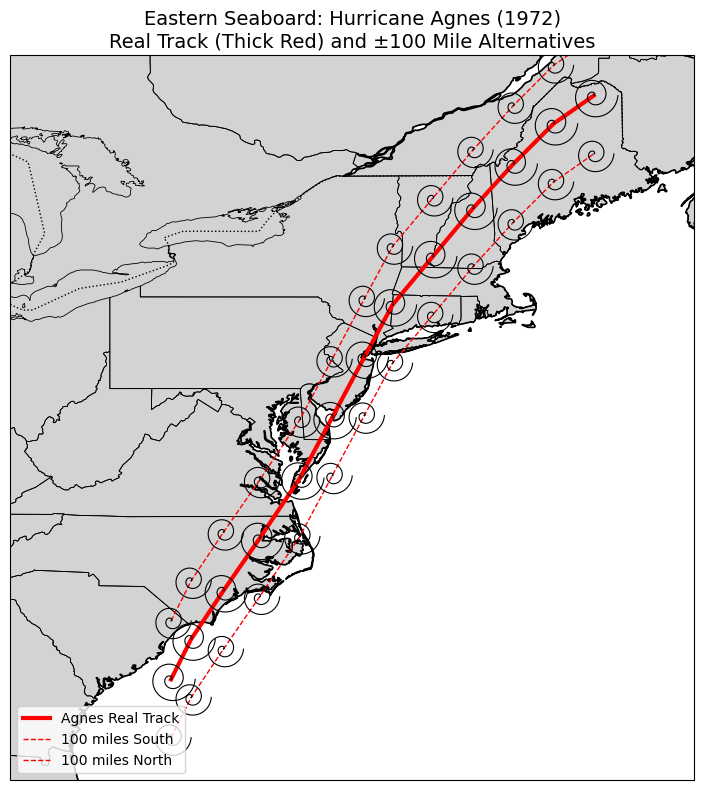

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Hurricane Agnes 1972 (Eastern Seaboard segment)
# --------------------------------------------------

lats = np.array([
    32.5, 33.5, 34.7, 36.0, 37.5,
    39.0, 40.5, 41.8, 43.0, 44.2,
    45.3, 46.3, 47.0
])

lons = np.array([
    -79.0, -78.5, -77.7, -76.8, -75.8,
    -75.0, -74.2, -73.5, -72.5, -71.5,
    -70.5, -69.5, -68.5
])

# --------------------------------------------------
# Create ±100 mile tracks (~1.45° latitude)
# --------------------------------------------------

shift_deg = 100 / 69.0  # ~1.45 degrees latitude

south_lats = lats - shift_deg
north_lats = lats + shift_deg

# --------------------------------------------------
# Function to draw schematic hurricane spiral
# --------------------------------------------------

def draw_hurricane_icon(ax, lon, lat, size=0.5):
    theta = np.linspace(0, 4 * np.pi, 200)
    r = np.linspace(0.0, size, 200)

    x = lon + r * np.cos(theta)
    y = lat + r * np.sin(theta)

    ax.plot(x, y,
            color="black",
            linewidth=0.8,
            transform=ccrs.PlateCarree(),
            zorder=5)

# --------------------------------------------------
# Plot map
# --------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-83, -66, 30, 48], crs=ccrs.PlateCarree())

# High-resolution coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# --------------------------------------------------
# Plot tracks
# --------------------------------------------------

# Real track (thick solid red)
ax.plot(lons, lats,
        color="red",
        linewidth=3,
        label="Agnes Real Track",
        transform=ccrs.PlateCarree())

# South track (thin dashed red)
ax.plot(lons, south_lats,
        color="red",
        linewidth=1,
        linestyle="--",
        label="100 miles South",
        transform=ccrs.PlateCarree())

# North track (thin dashed red)
ax.plot(lons, north_lats,
        color="red",
        linewidth=1,
        linestyle="--",
        label="100 miles North",
        transform=ccrs.PlateCarree())

# --------------------------------------------------
# Add hurricane schematic icons
# --------------------------------------------------

for lon, lat in zip(lons, lats):
    draw_hurricane_icon(ax, lon, lat, size=0.6)

for lon, lat in zip(lons, south_lats):
    draw_hurricane_icon(ax, lon, lat, size=0.5)

for lon, lat in zip(lons, north_lats):
    draw_hurricane_icon(ax, lon, lat, size=0.5)

# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.title("Eastern Seaboard: Hurricane Agnes (1972)\n"
          "Real Track (Thick Red) and ±100 Mile Alternatives",
          fontsize=14)

plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


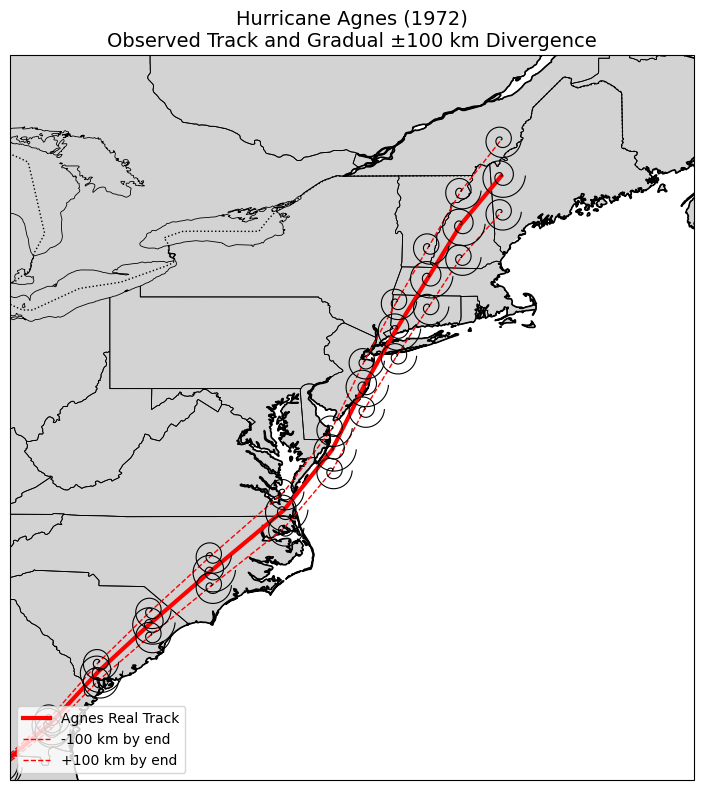

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Hurricane Agnes 1972 (Eastern Seaboard segment)
# --------------------------------------------------



# 6-hourly UTC positions (approximate best-track from HURDAT2)
lats = np.array([
    29.5, 30.3, 31.4, 32.7, 33.9,
    35.2, 36.7, 38.2, 39.8, 41.2,
    42.5, 43.8, 45.0
])

lons = np.array([
    -84.5, -83.3, -82.0, -80.8, -79.5,
    -78.0, -76.2, -75.0, -74.2, -73.4,
    -72.6, -71.8, -70.8
])

# --------------------------------------------------
# Create gradual ±100 km divergence
# --------------------------------------------------

max_shift_km = 100
km_per_deg_lat = 111.0
max_shift_deg = max_shift_km / km_per_deg_lat  # ~0.9°

# Gradual ramp from 0 to max_shift
n = len(lats)
ramp = np.linspace(0, 1, n)

north_lats = lats + ramp * max_shift_deg
south_lats = lats - ramp * max_shift_deg

# --------------------------------------------------
# Hurricane spiral drawing function
# --------------------------------------------------

def draw_hurricane_icon(ax, lon, lat, size=0.5):
    theta = np.linspace(0, 4 * np.pi, 200)
    r = np.linspace(0.0, size, 200)

    x = lon + r * np.cos(theta)
    y = lat + r * np.sin(theta)

    ax.plot(x, y,
            color="black",
            linewidth=0.8,
            transform=ccrs.PlateCarree(),
            zorder=5)

# --------------------------------------------------
# Plot map
# --------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-83, -66, 30, 48], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# --------------------------------------------------
# Plot tracks
# --------------------------------------------------

# Real track
ax.plot(lons, lats,
        color="red",
        linewidth=3,
        label="Agnes Real Track",
        transform=ccrs.PlateCarree())

# South divergence
ax.plot(lons, south_lats,
        color="red",
        linewidth=1,
        linestyle="--",
        label="-100 km by end",
        transform=ccrs.PlateCarree())

# North divergence
ax.plot(lons, north_lats,
        color="red",
        linewidth=1,
        linestyle="--",
        label="+100 km by end",
        transform=ccrs.PlateCarree())

# --------------------------------------------------
# Add hurricane icons
# --------------------------------------------------

for lon, lat in zip(lons, lats):
    draw_hurricane_icon(ax, lon, lat, size=0.6)

for lon, lat in zip(lons, south_lats):
    draw_hurricane_icon(ax, lon, lat, size=0.5)

for lon, lat in zip(lons, north_lats):
    draw_hurricane_icon(ax, lon, lat, size=0.5)

# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.title("Hurricane Agnes (1972)\n"
          "Observed Track and Gradual ±100 km Divergence",
          fontsize=14)

plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


Storms found: ['UNNAMED' 'ABLE' 'BAKER' 'CHARLIE' 'DOG' 'EASY' 'FOX' 'GEORGE' 'HOW'
 'ITEM' 'JIG' 'KING' 'LOVE' 'MIKE' 'ALICE' 'BARBARA' 'CAROL' 'DOLLY'
 'EDNA' 'FLORENCE' 'GAIL' 'HAZEL' 'GILDA' 'BRENDA' 'CONNIE' 'DIANE'
 'EDITH' 'FLORA' 'GLADYS' 'IONE' 'HILDA' 'JANET' 'KATIE' 'ANNA' 'BETSY'
 'CARLA' 'DORA' 'ETHEL' 'FLOSSY' 'GRETA' 'AUDREY' 'BERTHA' 'CARRIE'
 'DEBBIE' 'ESTHER' 'FRIEDA' 'ALMA' 'BECKY' 'CLEO' 'DAISY' 'ELLA' 'FIFI'
 'GERDA' 'HELENE' 'ILSA' 'JANICE' 'ARLENE' 'BEULAH' 'CINDY' 'DEBRA'
 'GRACIE' 'HANNAH' 'IRENE' 'JUDITH' 'ABBY' 'DONNA' 'FRANCES' 'HATTIE'
 'JENNY' 'INGA' 'CELIA' 'GINNY' 'HELENA' 'ISBELL' 'ELENA' 'DOROTHY'
 'FAITH' 'HALLIE' 'INEZ' 'LOIS' 'KENDRA' 'CHLOE' 'DORIA' 'FERN' 'GINGER'
 'HEIDI' 'CANDY' 'BLANCHE' 'CAMILLE' 'EVE' 'FRANCELIA' 'HOLLY' 'KARA'
 'LAURIE' 'MARTHA' 'FELICE' 'BETH' 'KRISTY' 'LAURA' 'ALPHA' 'AGNES'
 'BETTY' 'DAWN' 'DELTA' 'ALFA' 'CHRISTINE' 'DELIA' 'ELLEN' 'FRAN' 'CARMEN'
 'ELAINE' 'GERTRUDE' 'AMY' 'CAROLINE' 'DORIS' 'ELOISE' 'FAYE' 'BELLE'
 'DOT

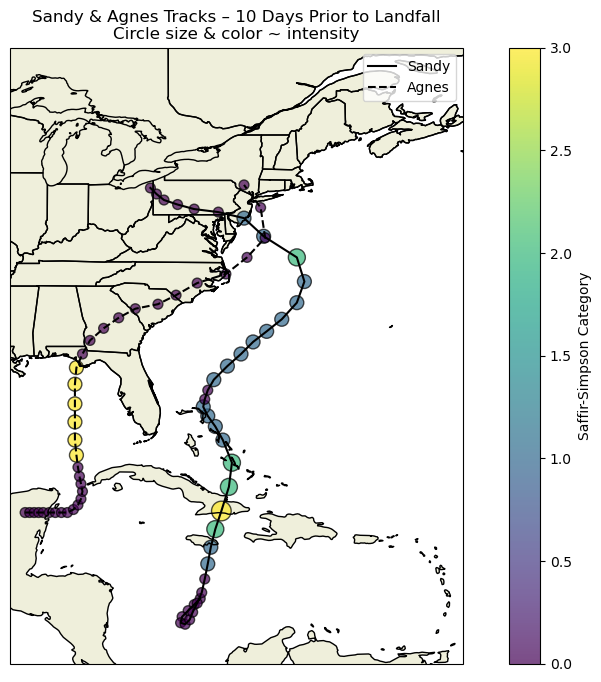

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
import re


def category(w):
    if pd.isna(w) or w < 0: return 0
    if w >= 137: return 5
    if w >= 113: return 4
    if w >= 96: return 3
    if w >= 83: return 2
    if w >= 64: return 1
    if w >= 34: return 0
    return 0


file_path = "hurdat2-1851-2024-040425.txt"  # your local file

# --- Parse file robustly ---
records = []

with open(file_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    
    # Header line detection: AL + 4 digits
    if re.match(r'^AL\d{6,}', line):
        parts = line.split(',')
        storm_name = parts[1].strip().upper()
        try:
            count = int(parts[2].strip())
        except:
            count = 0

        # Read next 'count' data lines
        for j in range(1, count+1):
            if i+j >= len(lines):
                continue
            data_line = lines[i+j].strip()
            dp = [x.strip() for x in data_line.split(',') if x.strip() != '']
            if len(dp) < 6:
                continue
            try:
                date = dp[0]
                time = dp[1]
                lat_str = dp[3]
                lon_str = dp[4]
                wind = int(dp[5])

                lat = float(lat_str[:-1])
                lon = -float(lon_str[:-1])

                dt_str = date + time
                dt = pd.to_datetime(dt_str, format='%Y%m%d%H%M', errors='coerce')

                records.append([storm_name, dt, lat, lon, wind])
            except Exception:
                continue

        i += count + 1
    else:
        i += 1

df = pd.DataFrame(records, columns=['storm','datetime','lat','lon','wind'])

# Check what storm names were read
print("Storms found:", df['storm'].unique())

# --- Saffir-Simpson category ---


df['cat'] = df['wind'].apply(category)


# --- Filter Sandy and Agnes robustly ---
sandy = df[df['storm'].str.contains('SANDY', case=False)].sort_values('datetime')
agnes = df[df['storm'].str.contains('AGNES', case=False)].sort_values('datetime')

print("Sandy entries:", len(sandy))
print("Agnes entries:", len(agnes))

if sandy.empty or agnes.empty:
    raise ValueError("Storm not found — check the storm names in the file!")

# --- 10 days prior to last recorded track ---
sandy_pre10 = sandy[sandy['datetime'] >= sandy['datetime'].max() - timedelta(days=10)]
agnes_pre10 = agnes[agnes['datetime'] >= agnes['datetime'].max() - timedelta(days=10)]

# --- Plot ---
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90, -60, 10, 50])
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)

cmap = plt.get_cmap('viridis')

# Ensure no NaN in cat
sandy_pre10 = sandy_pre10.dropna(subset=['lat','lon','cat'])
agnes_pre10 = agnes_pre10.dropna(subset=['lat','lon','cat'])



# Sandy solid
ax.plot(sandy_pre10['lon'], sandy_pre10['lat'], '-', color='black', label='Sandy')
sc_sandy = ax.scatter(
    sandy_pre10['lon'], sandy_pre10['lat'],
    c=sandy_pre10['cat'], cmap=cmap,
    s=(sandy_pre10['cat']+1)*50,
    edgecolor='k', alpha=0.7,
    transform=ccrs.PlateCarree()
)

# Agnes dashed
ax.plot(agnes_pre10['lon'], agnes_pre10['lat'], '--', color='black', label='Agnes')
sc_agnes = ax.scatter(
    agnes_pre10['lon'], agnes_pre10['lat'],
    c=agnes_pre10['cat'], cmap=cmap,
    s=(agnes_pre10['cat']+1)*50,
    edgecolor='k', alpha=0.7,
    transform=ccrs.PlateCarree()
)







#ax.plot(sandy_pre10['lon'], sandy_pre10['lat'], '-', color='black', label='Sandy')
#ax.scatter(sandy_pre10['lon'], sandy_pre10['lat'], c=sandy_pre10['cat'], cmap=cmap,
#           s=(sandy_pre10['cat']+1)*50, edgecolor='k', alpha=0.7, transform=ccrs.PlateCarree())

#ax.plot(agnes_pre10['lon'], agnes_pre10['lat'], '--', color='black', label='Agnes')
#ax.scatter(agnes_pre10['lon'], agnes_pre10['lat'], c=agnes_pre10['cat'], cmap=cmap,
#           s=(agnes_pre10['cat']+1)*50, edgecolor='k', alpha=0.7, transform=ccrs.PlateCarree())

plt.colorbar(sc_sandy, label='Saffir-Simpson Category')
plt.legend()
plt.title('Sandy & Agnes Tracks – 10 Days Prior to Landfall\nCircle size & color ~ intensity')
plt.show()


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
import re
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import cartopy.io.shapereader as shpreader

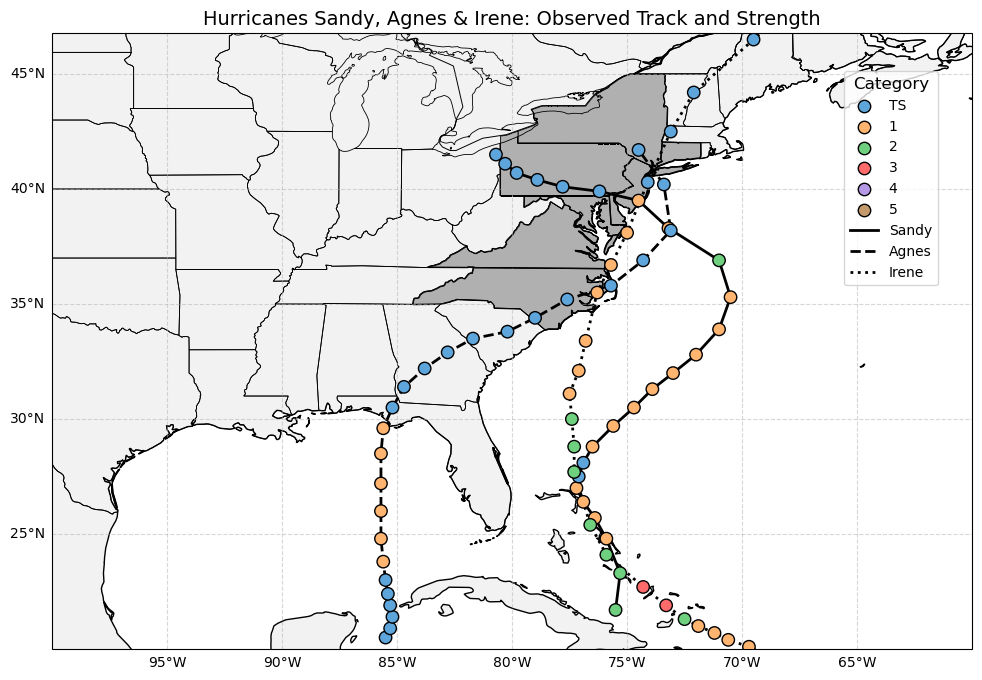

In [57]:
# --- File ---
file_path = "hurdat2-1851-2024-040425.txt"  # local file path

# --- Parse HURDAT2 ---
records = []
with open(file_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    if re.match(r'^AL\d{6,}', line):
        parts = line.split(',')
        storm_name = parts[1].strip().upper()
        count = int(parts[2].strip())

        for j in range(1, count + 1):
            dp = [x.strip() for x in lines[i + j].split(',') if x.strip()]
            if len(dp) < 6:
                continue
            try:
                dt = pd.to_datetime(dp[0] + dp[1], format='%Y%m%d%H%M')
                lat = float(dp[3][:-1])
                lon = -float(dp[4][:-1])
                wind = float(dp[5])
                records.append([storm_name, dt, lat, lon, wind])
            except:
                continue

        i += count + 1
    else:
        i += 1

df = pd.DataFrame(records, columns=['storm','datetime','lat','lon','wind'])

# --- Category ---
def category(w):
    if w >= 137: return 5
    if w >= 113: return 4
    if w >= 96:  return 3
    if w >= 83:  return 2
    if w >= 64:  return 1
    if w >= 34:  return 0
    return 0

df['cat'] = df['wind'].apply(category)

# --- Select storms ---
sandy  = df[df['storm'].str.contains('SANDY')].sort_values('datetime')
agnes  = df[df['storm'].str.contains('AGNES')].sort_values('datetime')
#isabel = df[df['storm'].str.contains('ISABEL')].sort_values('datetime')
harvey = df[df['storm'].str.contains('IRENE')].sort_values('datetime')


# --- 6 days prior to last recorded track ---
sandy  = sandy[sandy['datetime'] >= sandy['datetime'].max() - timedelta(days=6)]
agnes  = agnes[agnes['datetime'] >= agnes['datetime'].max() - timedelta(days=6)]
#isabel = isabel[isabel['datetime'] >= isabel['datetime'].max() - timedelta(days=6)]
harvey = harvey[harvey['datetime'] >= harvey['datetime'].max() - timedelta(days=12)]

# --- Colors ---
#colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']  # TS,1-5
colors = [
    '#5DA5DA',  # TS  (lighter blue)
    '#FFB570',  # 1   (lighter orange)
    '#6FD07F',  # 2   (lighter green)
    '#FF6B6B',  # 3   (lighter red)
    '#B699E6',  # 4   (lighter purple)
    '#C49A6C']   # 5   (lighter brown)


cmap = ListedColormap(colors)
norm = BoundaryNorm([0,1,2,3,4,5,6], cmap.N)
circle_size = 80

# --- Plot ---
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-100,-60,20,45])

# Light gray land and ocean
ax.add_feature(cfeature.LAND, facecolor='#f2f2f2', zorder=0)  # very light gray
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

# Keep borders ON
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.6)

# --- Highlight selected states (darker gray) ---
shpfilename = shpreader.natural_earth(
    resolution='50m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shpreader.Reader(shpfilename)

highlight_states = [
    'North Carolina','Virginia','Maryland','Delaware',
    'Pennsylvania','New York','New Jersey','Connecticut'
]

for state in reader.records():
    if state.attributes['admin'] == 'United States of America':
        if state.attributes['name'] in highlight_states:
            ax.add_geometries(
                [state.geometry],
                ccrs.PlateCarree(),
                facecolor='#b0b0b0',   # darker gray
                edgecolor='black',
                linewidth=0.6,
                zorder=1
            )

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Track lines first
ax.plot(sandy['lon'], sandy['lat'], '-', color='black', lw=2, zorder=2)
ax.plot(agnes['lon'], agnes['lat'], '--', color='black', lw=2, zorder=2)
#ax.plot(isabel['lon'], isabel['lat'], ':', color='black', lw=2, zorder=2)
ax.plot(harvey['lon'], harvey['lat'], ':', color='black', lw=2, zorder=2)

# Circles on top
for storm in [sandy, agnes, harvey]:
    ax.scatter(storm['lon'], storm['lat'],
               c=storm['cat'], cmap=cmap, norm=norm,
               s=circle_size, edgecolor='k',
               transform=ccrs.PlateCarree(),
               zorder=5)

# Legend
legend_elements = []
labels = ['TS','1','2','3','4','5']

for i,lbl in enumerate(labels):
    legend_elements.append(
        plt.scatter([],[],s=circle_size,
                    color=colors[i],edgecolor='k',label=lbl)
    )

legend_elements.append(Line2D([0],[0],color='black',lw=2,label='Sandy'))
legend_elements.append(Line2D([0],[0],color='black',lw=2,linestyle='--',label='Agnes'))
legend_elements.append(Line2D([0],[0],color='black',lw=2,linestyle=':',label='Irene'))

ax.legend(handles=legend_elements,
          title='Category',
          loc='upper right',
          bbox_to_anchor=(0.97,0.95),
          fontsize=10,
          title_fontsize=12)

plt.title('Hurricanes Sandy, Agnes & Irene: Observed Track and Strength', fontsize=14)
plt.show()

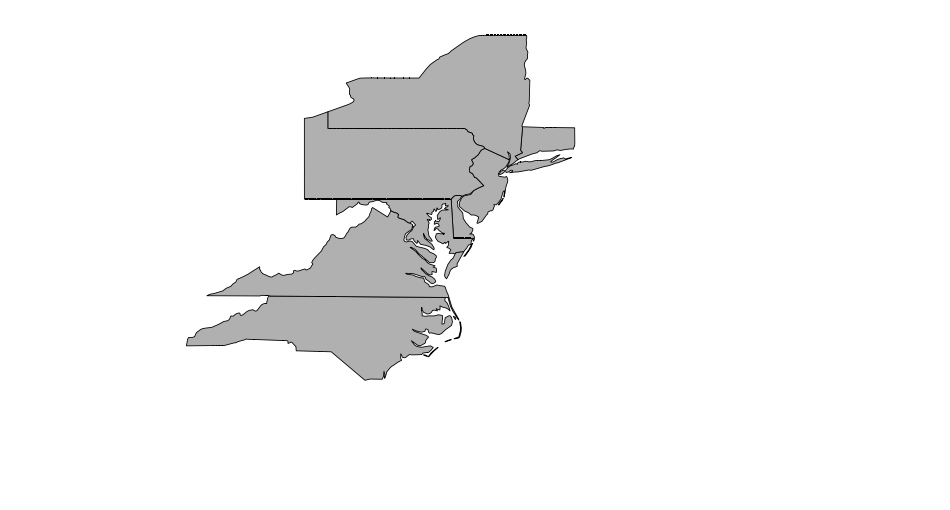

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
import re
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import cartopy.io.shapereader as shpreader

# --- File ---
file_path = "hurdat2-1851-2024-040425.txt"  # local file path

# --- Parse HURDAT2 ---
records = []
with open(file_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    if re.match(r'^AL\d{6,}', line):
        parts = line.split(',')
        storm_name = parts[1].strip().upper()
        count = int(parts[2].strip())

        for j in range(1, count + 1):
            dp = [x.strip() for x in lines[i + j].split(',') if x.strip()]
            if len(dp) < 4:
                continue
            try:
                dt = pd.to_datetime(dp[0] + dp[1], format='%Y%m%d%H%M')
                lat = float(dp[3][:-1])
                lon = -float(dp[4][:-1])
                wind = float(dp[5])
                records.append([storm_name, dt, lat, lon, wind])
            except:
                continue

        i += count + 1
    else:
        i += 1

df = pd.DataFrame(records, columns=['storm','datetime','lat','lon','wind'])

# --- Category ---
def category(w):
    if w >= 137: return 5
    if w >= 113: return 4
    if w >= 96:  return 3
    if w >= 83:  return 2
    if w >= 64:  return 1
    if w >= 34:  return 0
    return 0

df['cat'] = df['wind'].apply(category)

# --- Select storms ---
sandy  = df[df['storm'].str.contains('SANDY')].sort_values('datetime')
agnes  = df[df['storm'].str.contains('AGNES')].sort_values('datetime')
isabel = df[df['storm'].str.contains('ISABEL')].sort_values('datetime')

# --- 6 days prior to last recorded track ---
sandy  = sandy[sandy['datetime'] >= sandy['datetime'].max() - timedelta(days=3)]
agnes  = agnes[agnes['datetime'] >= agnes['datetime'].max() - timedelta(days=3)]
isabel = isabel[isabel['datetime'] >= isabel['datetime'].max() - timedelta(days=3)]

# --- Colors ---
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']  # TS,1-5
cmap = ListedColormap(colors)
norm = BoundaryNorm([0,1,2,3,4,5,6], cmap.N)
circle_size = 80

# --- Plot ---
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90,-60,30,45])

# Light gray land and ocean
##ax.add_feature(cfeature.LAND, facecolor='#f2f2f2', zorder=0)  # very light gray
#ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

# Keep borders ON
#ax.add_feature(cfeature.COASTLINE, linewidth=1)
#ax.add_feature(cfeature.BORDERS, linewidth=0.7)
#ax.add_feature(cfeature.STATES, linewidth=0.6)

# --- Highlight selected states (darker gray) ---
shpfilename = shpreader.natural_earth(
    resolution='50m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shpreader.Reader(shpfilename)

highlight_states = [
    'North Carolina','Virginia','Maryland','Delaware',
    'Pennsylvania','New York','New Jersey','Connecticut'
]

for state in reader.records():
    if state.attributes['admin'] == 'United States of America':
        if state.attributes['name'] in highlight_states:
            ax.add_geometries(
                [state.geometry],
                ccrs.PlateCarree(),
                facecolor='#b0b0b0',   # darker gray
                edgecolor='black',
                linewidth=0.6,
                zorder=1
            )

# Gridlines
#gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
#gl.top_labels = False
#gl.right_labels = False

# Track lines first
ax.set_axis_off()
#ax.plot(sandy['lon'], sandy['lat'], '-', color='black', lw=2, zorder=2)
#ax.plot(agnes['lon'], agnes['lat'], '--', color='black', lw=2, zorder=2)
#ax.plot(isabel['lon'], isabel['lat'], ':', color='black', lw=2, zorder=2)

# Circles on top
#for storm in [sandy, agnes, isabel]:
#    ax.scatter(storm['lon'], storm['lat'],
#               c=storm['cat'], cmap=cmap, norm=norm,
#               s=circle_size, edgecolor='k',
#               transform=ccrs.PlateCarree(),
#               zorder=5)

# Legend
#legend_elements = []
#labels = ['TS','1','2','3','4','5']

#for i,lbl in enumerate(labels):
#    legend_elements.append(
#        plt.scatter([],[],s=circle_size,
#                    color=colors[i],edgecolor='k',label=lbl)
#    )

#legend_elements.append(Line2D([0],[0],color='black',lw=2,label='Sandy'))
#legend_elements.append(Line2D([0],[0],color='black',lw=2,linestyle='--',label='Agnes'))
#legend_elements.append(Line2D([0],[0],color='black',lw=2,linestyle=':',label='Isabel'))

#ax.legend(handles=legend_elements,
#          title='Category',
#          loc='upper right',
#          bbox_to_anchor=(0.97,0.95),
##          fontsize=10,
#          title_fontsize=12)

#plt.title('Hurricanes Sandy, Agnes & Isabel: Observed Track and Strength', fontsize=14)
plt.show()